# EMVB

第一类：检索阶段超参数（不需要重建索引，变化时只跑检索，速度快）

这些参数控制在线查询时的候选集大小和截断阈值，是调节 **QPS vs Recall/MRR** 曲线的核心。您可以通过 `--param` 指定它们，所有取值共用同一个基础索引。

| 参数名 (`--param`) | 对应论文变量 | 默认基线值 | 作用机制（影响趋势） |
| :--- | :--- | :--- | :--- |
| **`nprobe`** | 探测聚类数 | 4 | **最核心参数**。增大则召回率（Recall/MRR）上升，但扫描倒排链变长，**QPS 显著下降**。 |
| **`out_second_stage`** | 精排候选数 | 1024 (k=100) | 增大使更多文档进入 PQ 打分阶段，MRR 上限提升，但计算开销增大，**QPS 下降**。 |
| **`n_doc_to_score`** | 粗排候选数 | 4000 | 控制位向量过滤后的保留文档数。增大可保证高召回，但后续排序压力增大，**QPS 降低**。 |
| **`thresh`** | 预过滤阈值 (th) | 0.4 | 调高则位向量更稀疏，过滤更快（**QPS 提升**），但可能误伤相关文档（Recall/MRR 微降）。 |
| **`thresh_query`** | 动态词项过滤阈值 (th_r) | 0.5 | 调高则跳过更多残差计算（**QPS 提升**），MRR 可能轻微下滑（论文图 5 显示 0.5 是甜点）。 |

---

第二类：索引构建阶段超参数（影响向量压缩与存储结构，变化时需要重建索引）

这些参数改变了底层的乘积量化（PQ）或倒排索引（IVF）结构。调整它们会移动整个 **QPS-Accuracy 帕累托前沿**（例如 `pq_m=16` 整体比 `pq_m=32` 快但略差）。**注意**：变化这些参数时，每个取值都会从头构建一次索引（耗时较长）。

| 参数名 (`--param`) | 对应论文变量 | 默认基线值 | 作用机制（影响趋势） |
| :--- | :--- | :--- | :--- |
| **`pq_m`** | PQ 子向量数 (m) | 32 | **存储/计算核心**。`16` 时内存小、解压快（高 QPS，低精度）；`32` 时内存大、计算慢（低 QPS，高 MRR/Recall）。 |
| **`nlist`** | IVF 聚类中心数 | 4096 | 影响倒排拉链的粒度。越大则每个拉链内文档越少，检索精度略升，但可能使内存访问分散，间接影响 QPS。 |
| **`nbits`** | PQ 编码位数 | 8 | 论文和 EMVB 代码硬编码为 8 位（否则 C++ 读取会出错）。一般不建议改动，但脚本支持扫描（如 8, 16）。 |
| **`metric`** | 距离度量 | l2 | 改变相似度计算方式（`l2` 或 `ip`）。会影响质心和残差的分布，进而影响检索质量与速度。 |
| **`train_size`** | FAISS 训练样本数 | 自动 (max 100k) | 控制 K-Means 聚类训练时的样本量。增大可能提升索引质量（Recall），但会增加索引构建时间，不影响在线 QPS。 |

In [ ]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_qps_metrics_by_k(csv_file):
    """
    根据 CSV 文件绘制 QPS 与 MRR、Recall 的关系图，按 k 值分组。

    参数:
        csv_file (str): CSV 文件的路径，必须包含 'qps', 'k', 'mrr', 'recall' 列。
    
    返回:
        None，但会在 CSV 同目录下保存 PNG 图片并显示图表。
    """
    # 读取数据
    df = pd.read_csv(csv_file)
    
    # 按 QPS 升序排序
    df_sorted = df.sort_values('qps')
    
    # 获取所有不同的 k 值
    ks = df_sorted['k'].unique()
    
    # 定义颜色和标记
    colors = {10: 'blue', 100: 'red'}
    markers = {10: 'o', 100: 's'}
    
    # 创建上下两个子图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
    
    # 绘制每个 k 的曲线
    for k in ks:
        df_k = df_sorted[df_sorted['k'] == k]
        qps = df_k['qps']
        mrr = df_k['mrr']
        recall = df_k['recall']
        
        ax1.plot(qps, mrr, marker=markers[k], linestyle='-', 
                 color=colors[k], label=f'MRR (k={k})')
        ax2.plot(qps, recall, marker=markers[k], linestyle='-', 
                 color=colors[k], label=f'Recall (k={k})')
    
    ax1.set_ylabel('MRR')
    ax1.set_title('QPS vs MRR')
    ax1.grid(True)
    ax1.legend()
    
    ax2.set_xlabel('QPS (Queries Per Second)')
    ax2.set_ylabel('Recall')
    ax2.set_title('QPS vs Recall')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    
    # 保存图片（与 CSV 同目录，同名 .png）
    dir_name = os.path.dirname(csv_file)
    base_name = os.path.basename(csv_file)
    name_without_ext = os.path.splitext(base_name)[0]
    save_path = os.path.join(dir_name, name_without_ext + '.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图片已保存至：{save_path}")
    
    plt.show()

## Scidocs

In [ ]:
!!!  ratios  !!!

In [ ]:
# Build An EMVB Index

cd EMVB
mkdir -p logs

python -u prepare_emvb_data.py \
  --base-embeddings /data1/chenyifeng/scidocs/colbert/corpus_points.npy \
  --base-offsets /data1/chenyifeng/scidocs/colbert/corpus_offsets.npy \
  --query-embeddings /data1/chenyifeng/scidocs/colbert/query_points.npy \
  --query-offsets /data1/chenyifeng/scidocs/colbert/query_offsets.npy \
  --output-dir /data1/chenyifeng/MultiVector-Backup/EMVB/work/indexes/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32 \
  --nlist 4096 \
  --pq-m 32 \
  --add-batch-size 200000 \
  --faiss-threads 48 \
  2>&1 | tee /data1/chenyifeng/MultiVector-Backup/EMVB/logs/prepare_scidocs_colbert_simple.log

In [ ]:
# Run The Ratio Sweep

cd EMVB
mkdir -p /data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32

python run_emvb_ratio_sweep.py \
  --dataset scidocs \
  --dataset-dir /data1/chenyifeng/scidocs/beir \
  --split test \
  --index-dir /data1/chenyifeng/MultiVector-Backup/EMVB/work/indexes/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32 \
  --results-dir /data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32 \
  --ratios 0.25 0.5 1 2 4 8 16 32\
  --k-values 10 100 \
  --query-id-mode positional

图片已保存至：/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.png


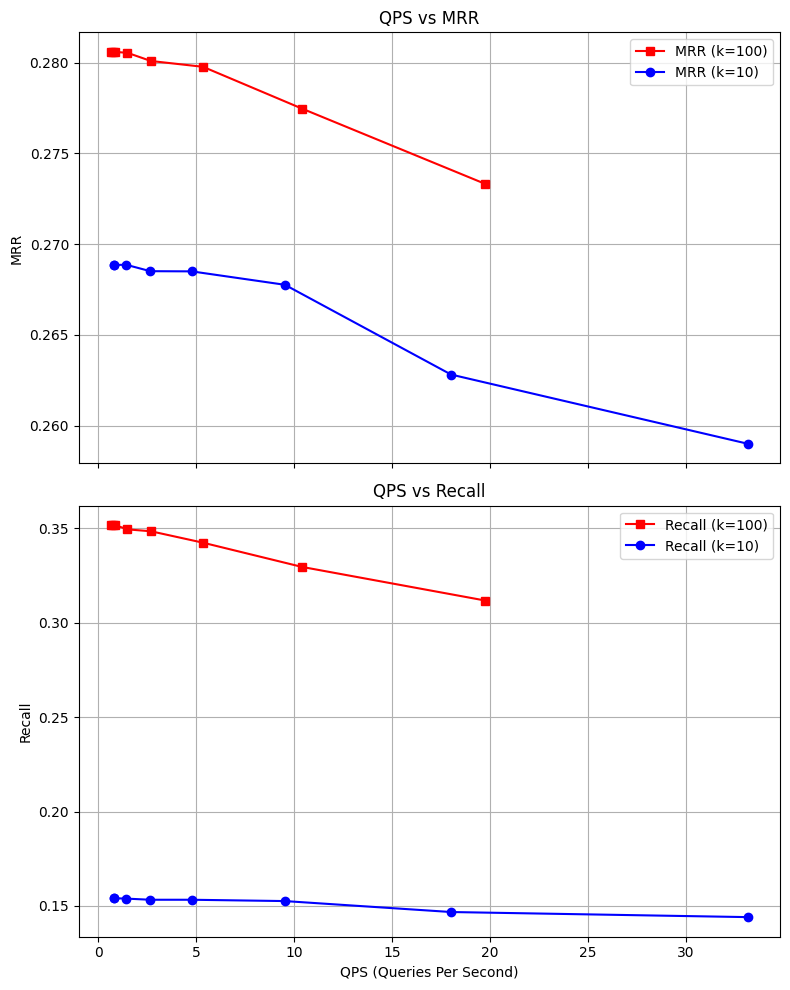

In [ ]:
# plot

plot_qps_metrics_by_k('/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.csv')

## Fiqa

In [ ]:
cut -f1 /data1/chenyifeng/Data_backup/fiqa/beir/qrels/test.tsv | sort -u | wc -l
649
cut -f1 /data1/chenyifeng/MultiVector-Backup/EMVB/work/results/fiqa_colbert/emvb_ivfpq_l2_nlist4096_m32/results_k10_r025.tsv | sort -u | wc -l
648

# 提取 qrels 中的所有查询 ID（排序）
cut -f1 /data1/chenyifeng/Data_backup/fiqa/beir/qrels/test.tsv | sort -u > /data1/chenyifeng/tmp/qrels_qids.txt

# 提取结果文件中的所有查询 ID（排序）
cut -f1 /data1/chenyifeng/MultiVector-Backup/EMVB/work/results/fiqa_colbert/emvb_ivfpq_l2_nlist4096_m32/results_k10_r025.tsv | sort -u > /data1/chenyifeng/tmp/results_qids.txt

# 找出在 qrels 中但不在结果中的查询 ID
comm -23 /data1/chenyifeng/tmp/qrels_qids.txt /data1/chenyifeng/tmp/results_qids.txt

In [ ]:
# Run one wrapper

cd EMVB

bash run_fiqa.sh


图片已保存至：/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.png


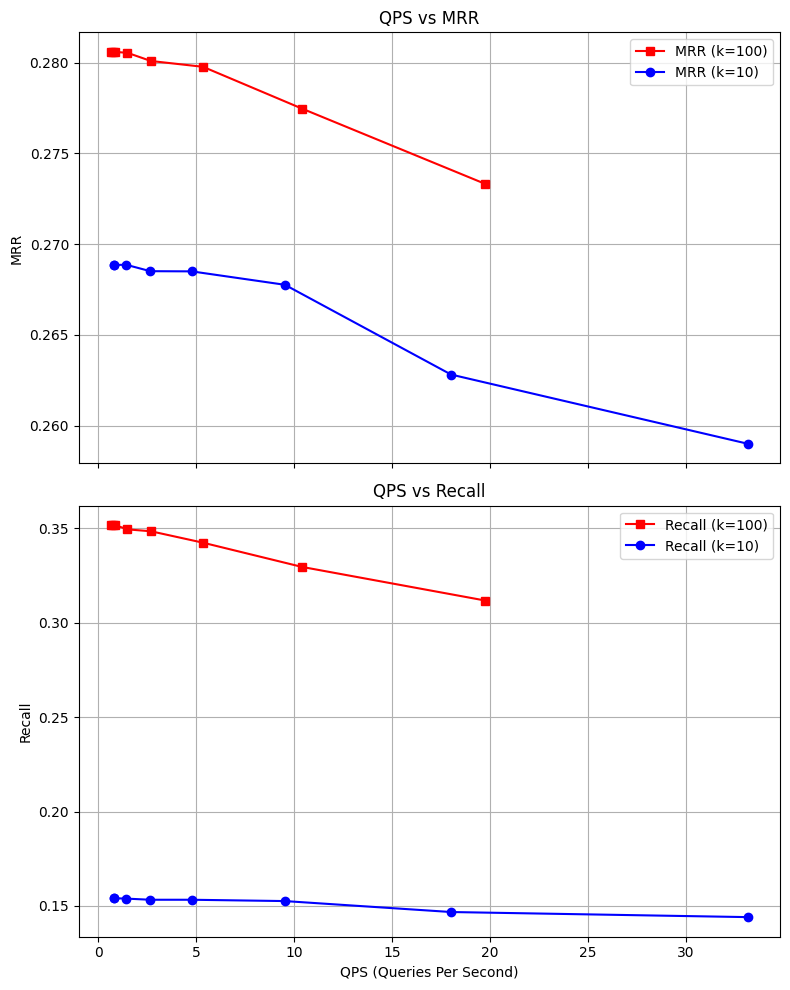

In [ ]:
# plot

plot_qps_metrics_by_k('/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/fiqa_colbert/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.csv')